# 数据集加载及预处理

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import numpy as np

# 加载加利福尼亚房价数据集
california_housing = fetch_california_housing(data_home='./data')
X, y = california_housing.data, california_housing.target

# 先划分数据集，然后在训练集上fit标准化器
from sklearn.model_selection import train_test_split

# 首先划分训练集和临时集（验证集+测试集）
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 再将临时集划分为验证集和测试集
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 数据标准化（只对特征进行标准化，标签不进行标准化）
# 在训练集上fit_transform，验证集和测试集只进行transform
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# 自定义Dataset类
class CaliforniaHousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (self.X[idx],self.X[idx][-2:]), self.y[idx].unsqueeze(0)

# 创建数据集
train_dataset = CaliforniaHousingDataset(X_train_scaled, y_train)
val_dataset = CaliforniaHousingDataset(X_val_scaled, y_val)
test_dataset = CaliforniaHousingDataset(X_test_scaled, y_test)

# 创建DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"数据集大小: 总计 {len(X)}")
print(f"训练集: {len(train_dataset)} 样本")
print(f"验证集: {len(val_dataset)} 样本")
print(f"测试集: {len(test_dataset)} 样本")
print(f"特征维度: {X.shape[1]}")


数据集大小: 总计 20640
训练集: 14448 样本
验证集: 3096 样本
测试集: 3096 样本
特征维度: 8


In [2]:
for (x1,x2),y in train_loader:
    print(x1.shape)
    print(x2.shape)
    print(y.shape)
    break

torch.Size([64, 8])
torch.Size([64, 2])
torch.Size([64, 1])


In [3]:


# 演示批量情况
print(f"\n批量情况演示:")
y_batch = torch.tensor([1.2, 2.3, 3.4])  # 3个样本的标签
print(f"批量标签原始形状: {y_batch.shape}")
y_batch_unsqueezed = y_batch.unsqueeze(1)  # 在第1维增加维度
print(f"批量标签unsqueeze(1)后形状: {y_batch_unsqueezed.shape}")
print(f"批量标签内容:\n{y_batch_unsqueezed}")



批量情况演示:
批量标签原始形状: torch.Size([3])
批量标签unsqueeze(1)后形状: torch.Size([3, 1])
批量标签内容:
tensor([[1.2000],
        [2.3000],
        [3.4000]])


# 搭建模型

In [4]:
class WideDeep(nn.Module):
    def __init__(self, input_dim=(8,2)):
        super().__init__()
        self.deep = nn.Sequential(
            nn.Linear(input_dim[1], 30), #30个神经元
            nn.ReLU(),
            nn.Linear(30, 30), #30个神经元
            nn.ReLU()
            )
        # pytorch 需要自行计算输出输出维度
        self.output_layer = nn.Linear(30 + input_dim[0], 1)
        
        # 初始化权重
        self.init_weights()
        
    def init_weights(self):
        """使用 xavier 均匀分布来初始化全连接层的权重 W"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
        
    def forward(self, x_wide, x_deep):
        # x.shape [batch size, 2]
        deep_output = self.deep(x_deep)
        # print(deep_output.shape) # [batch size, 30]
        # concat [batch size, 30] with x [batch size 8]，得到 [batch size, 38]
        concat = torch.cat([x_wide, deep_output], dim=1)
        logits = self.output_layer(concat) # 输出层，输入维度是 38，输出维度是 1
        # logits.shape [batch size, 1]
        return logits


In [5]:
# 编写前向计算验证上面模型

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 实例化模型，并移动到设备
model = WideDeep(input_dim=(8,2)).to(device)

# 创建模拟输入：wide部分(batch, 8)，deep部分(batch, 2)
x_wide = torch.randn(4, 8).to(device)
x_deep = torch.randn(4, 2).to(device)

# 前向计算，得到输出
output = model(x_wide, x_deep)

print(f"x_wide形状: {x_wide.shape}")
print(f"x_deep形状: {x_deep.shape}")
print(f"模型输出形状: {output.shape}")
print(f"模型输出内容:\n{output}")


使用设备: cuda
x_wide形状: torch.Size([4, 8])
x_deep形状: torch.Size([4, 2])
模型输出形状: torch.Size([4, 1])
模型输出内容:
tensor([[-1.2485],
        [ 0.4785],
        [ 0.6124],
        [ 0.5641]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [6]:
@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    for (datas_wide,datas_deep), labels in dataloader:
        datas_deep = datas_deep.to(device)
        datas_wide = datas_wide.to(device)
        labels = labels.to(device)
        # 前向计算
        logits = model(datas_wide, datas_deep)
        loss = loss_fct(logits, labels)         # 验证集损失
        loss_list.append(loss.item())
        
    return np.mean(loss_list)

In [7]:
# 导入训练模块
from wangdao_train import Trainer, EarlyStopping, ModelCheckpoint

#需要pip install tqdm
from tqdm.auto import tqdm


# 初始化损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数，适用于回归任务
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 训练
def training(
    model, 
    train_loader, 
    val_loader, 
    epoch, 
    loss_fct, 
    optimizer, 
    tensorboard_callback=None,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }
    
    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            # training
            for (datas_wide,datas_deep), labels in train_loader:#和上面自定义的dataset是一致的
                datas_deep = datas_deep.to(device)
                datas_wide = datas_wide.to(device)
                labels = labels.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 模型前向计算,因为forward中有两个参数
                logits = model(datas_wide,datas_deep)
                # 计算损失
                loss = loss_fct(logits, labels)
                # 梯度回传
                loss.backward()
                # 调整优化器，包括学习率的变动等
                optimizer.step()
 
                loss = loss.cpu().item()
                # record
                
                record_dict["train"].append({
                    "loss": loss, "step": global_step
                })
                
                # evaluating
                if global_step % eval_step == 0:
                    model.eval()
                    val_loss = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "step": global_step
                    })
                    model.train()
                    
                # udate step
                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})
        
    return record_dict
        

epoch = 10



model = model.to(device)
record = training(
    model, 
    train_loader, 
    val_loader, 
    epoch, 
    criterion, 
    optimizer,
    eval_step=len(train_loader)
    )

  0%|          | 0/2260 [00:00<?, ?it/s]

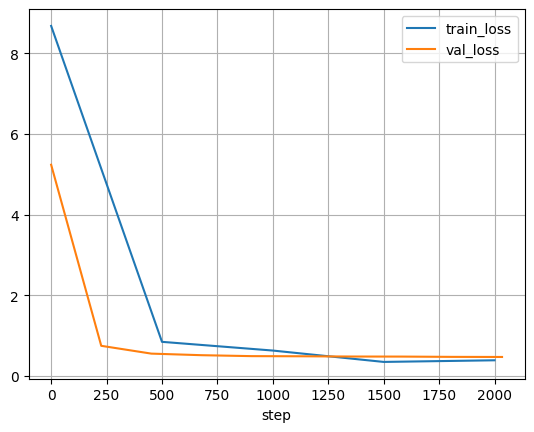

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
#画线要注意的是损失是不一定在零到1之间的
def plot_learning_curves(record_dict, sample_step=500):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    # plot
    for idx, item in enumerate(train_df.columns):
        plt.plot(train_df.index, train_df[item], label=f"train_{item}")
        plt.plot(val_df.index, val_df[item], label=f"val_{item}")
        plt.grid()
        plt.legend()
        # plt.xticks(range(0, train_df.index[-1], 10*sample_step), range(0, train_df.index[-1], 10*sample_step))
        plt.xlabel("step")

        plt.show()

plot_learning_curves(record, sample_step=500)  #横坐标是 steps